TokaMaker Example: Vertical stability control for ARC V3A {#doc_tMaker_ARC_ex3}
==========
This is based on the ARC V3A digital assets as described in Appendix A of Hillesheim et al, "Overview of the physics basis for the ARC fusion power plant" Journal of Plasma Physics (2026).  https://doi.org/10.1017/S0022377826101706

All files available on Zenodo at: https://zenodo.org/records/19498373

In this example we demonstrate:

 1. How to identify the vertically unstable mode of a free-boundary equilibrium and compute its growth rate
 2. How to evolve a vertically perturbed equilibrium in time with \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.step_td "step_td()"
 3. How to close a simple proportional-derivative (PD) feedback loop on a vertical stability coil (VSC) pair to arrest the resulting vertical displacement event (VDE)

This example builds the same equilibrium as \ref doc_tMaker_ARC_ex2 and uses the mesh built in \ref doc_tMaker_ARC_ex1.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk

## Build the reference equilibrium

The time-dependent study below starts from a converged free-boundary equilibrium, so we first repeat the inverse solve of \ref doc_tMaker_ARC_ex2. See that example for a detailed discussion of each step; here we simply collect them.

The ARC gEQDSK is sourced from [Zenodo](https://zenodo.org/records/19498373) and downloaded automatically below if not already present locally.

In [3]:
import urllib.request

_ZENODO = 'https://zenodo.org/records/19498373/files'

def _fetch(filename):
    if not os.path.exists(filename):
        print(f'Downloading {filename} from Zenodo...', end=' ', flush=True)
        urllib.request.urlretrieve(f'{_ZENODO}/{filename}?download=1', filename)
        print('done.')

_fetch('geqdsk-ARCv3a')

eqdsk = read_eqdsk('geqdsk-ARCv3a')

### Initialize TokaMaker and load the mesh
The ARC V3A mesh contains three passively conducting structures in addition to the coils: the inner and outer vacuum vessel shells and the blanket tank. The resistivity of each was assigned when the mesh was built, and it is these conductors that set the timescale of the vertical instability studied below.

In [4]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)
mygs.settings.maxits = 200

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('arc_v3a_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2,F0=eqdsk['rcentr']*eqdsk['bcentr'])

for name, cond in cond_dict.items():
    if 'eta' in cond:
        print('{0:15} eta = {1:.2E} Ohm-m'.format(name,cond['eta']))

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Base release:        v26.9
Development branch:  main
Revision id:         6b06573c

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.060E+02
    # of points  =    9281
    # of edges   =   27632
    # of cells   =   18352
    # of boundary points =     208
    # of boundary edges  =     208
    # of boundary cells  =     208
  Resolution statistics:
    hmin =  1.000E-02
    hrms =  1.236E-01
    hmax =  3.005E-01
  Surface grounded at vertex    2770


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix

### Define the vertical stability coil
The outermost up-down pair of poloidal field coils, `PF5U` and `PF5L`, is used as the vertical stability coil (VSC). Driving these two coils antisymmetrically (`+1` on the upper, `-1` on the lower) produces a radial field at the magnetic axis and therefore a vertical force on the plasma, while producing very little net vertical field. This same pair will be our control actuator in the time-dependent simulation.

During the inverse solve, \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_coil_vsc "set_coil_vsc()" exposes this antisymmetric combination as a virtual coil (`#VSC`) that the solver is free to adjust to help locate the vertically unstable equilibrium.

In [5]:
mygs.set_coil_vsc({'PF5U': 1.0, 'PF5L': -1.0})

coil_bounds = {key: [-100.E3, 100.E3] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

### Define targets, shape constraints, and regularization
We match the plasma current and on-axis pressure of the gEQDSK as "hard" targets and use its last closed flux surface as the `isoflux` shape constraint. For the coil regularization we apply a weak penalty on the current in each coil plus a much stronger penalty on the difference between each coil and its up-down mirror. The latter enforces an up-down symmetric coil set.

In [6]:
mygs.set_targets(Ip=abs(eqdsk['ip']), pax=eqdsk['pres'][0])
mygs.set_isoflux_constraints(eqdsk['rzout'].copy())

regularization_terms = []
for name in mygs.coil_sets:
    if name.endswith('L'):
        continue  # Upper coils only; the mirror term below ties each lower coil to its partner
    mirror = name[:-1]+'L'
    # Weak penalty on coil current amplitude to condition the fit
    regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
    # Strong penalty on up-down asymmetry
    regularization_terms.append(mygs.coil_reg_term({name: 1.0, mirror: -1.0},target=0.0,weight=1.E1))
# Weak penalty on the virtual VSC so the solver can still shift the plasma vertically
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

mygs.set_coil_reg(reg_terms=regularization_terms)

### Define flux functions
As in \ref doc_tMaker_ARC_ex2 we take the P' and F\*F' profiles directly from the gEQDSK we are reproducing.

In [7]:
psi_eqdsk = np.linspace(0.0,1.0,eqdsk['nr'])
psi_sample = np.linspace(0.0,1.0,50)

mygs.set_profiles(
    ffp_prof={'type': 'linterp', 'x': psi_sample, 'y': np.interp(psi_sample,psi_eqdsk,eqdsk['ffprim'])},
    pp_prof={'type': 'linterp', 'x': psi_sample, 'y': np.interp(psi_sample,psi_eqdsk,eqdsk['pprime'])})

### Compute the equilibrium
Finally we initialize $\psi$ and solve. We then save the resulting flux and coil currents, which define the operating point that the controller will be asked to hold.

In [8]:
mygs.init_psi(3.7, 0.0, 1.0, 1.8, 0.6)
_ = mygs.solve()

# Quiet the solver for the many time steps below
mygs.settings.pm = False
mygs.update_settings()

psi0 = mygs.get_psi(normalized=False)
coil_currents0, _ = mygs.get_coil_currents()
mygs.print_info()

Starting non-linear GS solver
     1 -5.6262E-02 -1.8421E-06  1.4032E+00  4.5205E+00 -1.1317E-03 -3.9876E+01
     2 -1.2170E+00 -1.4112E-06  6.1729E-01  4.6208E+00 -1.7764E-03 -5.5447E+00
     3 -1.5648E+00 -1.3143E-06  4.0931E-01  4.6663E+00 -9.7016E-04 -7.5284E+00
     4 -1.7226E+00 -1.2824E-06  4.3745E-01  4.6867E+00 -5.4254E-04 -1.2558E+01
     5 -1.8045E+00 -1.2692E-06  2.7333E-01  4.6958E+00 -3.0619E-04 -1.3900E+01
     6 -1.8492E+00 -1.2628E-06  1.5429E-01  4.6999E+00 -1.7230E-04 -1.4130E+01
     7 -1.8739E+00 -1.2595E-06  8.3568E-02  4.7018E+00 -9.4434E-05 -1.3996E+01
     8 -1.8873E+00 -1.2577E-06  4.4866E-02  4.7027E+00 -4.7827E-05 -1.3728E+01
     9 -1.8946E+00 -1.2568E-06  2.3652E-02  4.7030E+00 -1.9638E-05 -1.3476E+01
    10 -1.8984E+00 -1.2563E-06  1.2334E-02  4.7032E+00 -2.3363E-06 -1.3262E+01
    11 -1.9004E+00 -1.2560E-06  6.3708E-03  4.7033E+00  8.3885E-06 -1.3096E+01
    12 -1.9014E+00 -1.2559E-06  3.2915E-03  4.7033E+00  1.5086E-05 -1.2976E+01
    13 -1.9019E+00 -1.

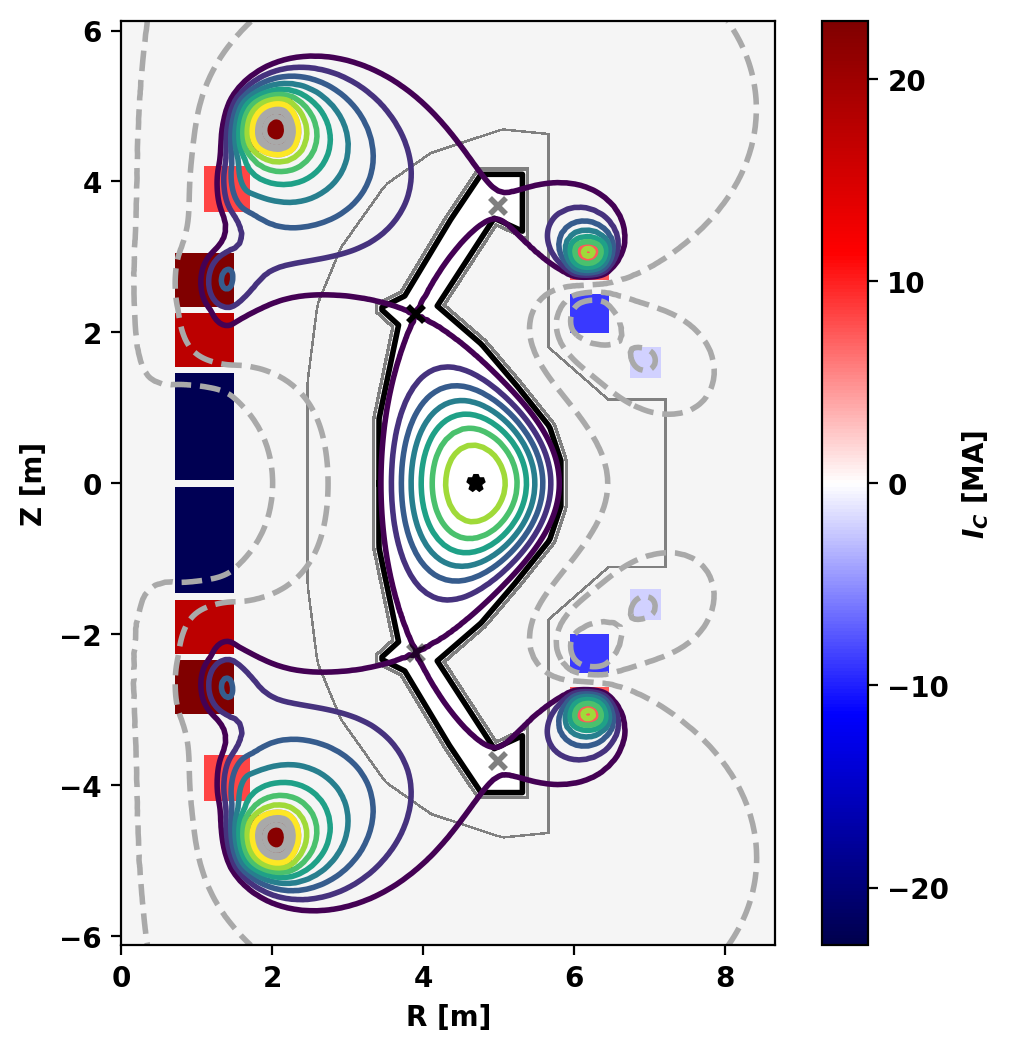

In [9]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,vacuum_nlevels=4)
ax.set_xlabel('R [m]')
_ = ax.set_ylabel('Z [m]')

## Linear stability

Before running any time-dependent simulation it is worth asking which mode we are trying to control and how fast it grows, since that sets both the timestep and the bandwidth the controller needs.

\ref OpenFUSIONToolkit.TokaMaker.TokaMaker.compute_linear_stability "compute_linear_stability()" returns growth rates $\gamma$ and the corresponding perturbed flux eigenvectors for the linearized time-dependent system. The `omega` argument is a localization point: the solver returns the modes whose growth rates lie closest to it.

In [10]:
growth_rates, eig_modes = mygs.compute_linear_stability(1.E2, 4, False)

print('Growth rates [1/s]:')
for gamma in growth_rates:
    print('  {0:10.3F}'.format(gamma))

gamma_vde = growth_rates[0]
print('\nVertical mode growth rate = {0:.2F} 1/s (growth time = {1:.1F} ms)'.format(
    gamma_vde, 1.E3/gamma_vde))

Growth rates [1/s]:
       7.000
      -3.713
      -6.306
      -8.996

Vertical mode growth rate = 7.00 1/s (growth time = 142.9 ms)


The vertical mode of ARC V3A grows on a timescale of order 100 ms, which is very slow compared to the Alfv&eacute;n time and by the standards of present-day tokamaks. This is a direct consequence of the thick, low-resistivity blanket tank and double-walled vacuum vessel seen above: the perturbed flux must diffuse resistively through all of that conducting structure before the plasma can move, so the passive structure does most of the stabilization and the active controller only has to handle what is left.

Plotting the eigenmode confirms its character. The perturbed flux is up-down antisymmetric and is concentrated around the plasma edge and in the conducting structures, which is exactly the signature of a rigid vertical shift.

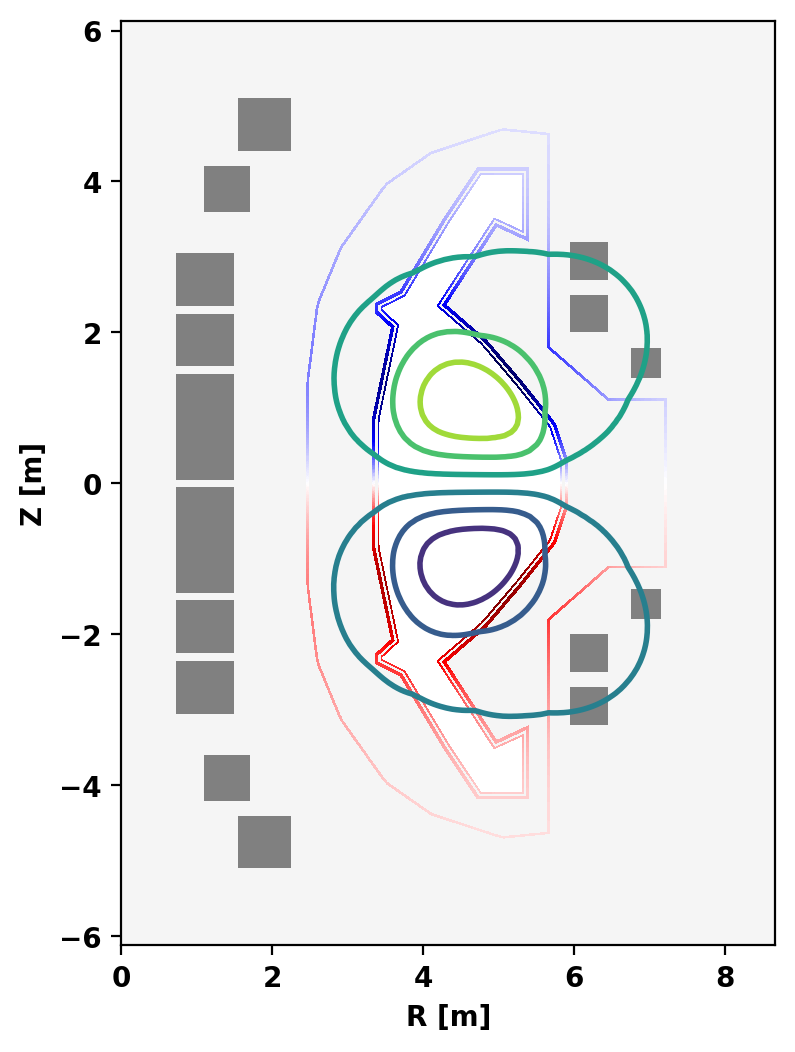

In [11]:
mode = eig_modes[0,:]
# Normalize the mode so that a positive amplitude corresponds to an upward shift
imax = abs(mode).argmax()
mode = mode*np.sign(mode[imax]*mygs.r[imax,1])/abs(mode).max()

fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,limiter_color=None)
mygs.plot_psi(fig,ax,psi=mode,normalized=False,plasma_nlevels=8,vacuum_nlevels=0,
              opoint_color=None,xpoint_color=None)
mygs.plot_eddy(fig,ax,dpsi_dt=mode*gamma_vde,colormap='seismic',symmap=True,clabel=None)
ax.set_xlabel('R [m]')
_ = ax.set_ylabel('Z [m]')

## Set up the control problem

### The VSC circuit
The controller commands a current $I_{VSC}$ in the antisymmetric PF5 combination, so that

$$ I_{PF5U} = I_{PF5}^0 + I_{VSC}, \qquad I_{PF5L} = I_{PF5}^0 - I_{VSC} $$

where $I_{PF5}^0$ is the (up-down symmetric) equilibrium current in the pair. A real power supply cannot change this current instantaneously: it applies a voltage across the circuit, and the current responds as $V = L_{VSC} \, dI_{VSC}/dt$. The effective inductance of the antisymmetric combination follows from the coil mutual inductance matrix returned by \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_coil_Lmat "get_coil_Lmat()".

In [12]:
Lmat = mygs.get_coil_Lmat()
id_U = mygs.coil_sets['PF5U']['id']
id_L = mygs.coil_sets['PF5L']['id']
L_VSC = Lmat[id_U,id_U] + Lmat[id_L,id_L] - 2.0*Lmat[id_U,id_L]

# Up-down symmetric part of the equilibrium PF5 current, which the controller leaves alone
I_PF5_bias = 0.5*(coil_currents0['PF5U'] + coil_currents0['PF5L'])

print('L_VSC       = {0:.3F} H'.format(L_VSC))
print('I_PF5 bias  = {0:.2F} kA/turn'.format(I_PF5_bias/1.E3))

L_VSC       = 1.389 H
I_PF5 bias  = -12.49 kA/turn


### The controller
We use a simple PD law on the vertical position of the magnetic axis, $Z_0$, which TokaMaker exposes as `mygs.o_point[1]`. The output of the controller is the **voltage** applied across the VSC circuit,

$$ V_{VSC} = -\left( K_P Z_0 + K_D \dot{Z}_0 \right), \qquad |V_{VSC}| \le V_{max} $$

and the coil current then follows by integrating the circuit equation above, $I_{VSC} \mathrel{+}= V_{VSC} \Delta t / L_{VSC}$. The proportional term supplies the restoring force and the derivative term damps the response; $K_P$ has units of V/m and $K_D$ of V-s/m.

The controller is not allowed to act until the displacement is actually large enough to be detected. The flag `control_on` latches to `True` the first time $|Z_0|$ exceeds a threshold `z0_thresh`, and the loop stays closed from then on. This sets the initial displacement the controller has to recover from. Here we use a 3 cm threshold.


In [13]:
def run_vde(K_P=0.0, K_D=0.0, dz_init=0.01, z0_thresh=0.03, nsteps=160, dt=5.E-3,
            V_max=3.E4, z_loss=0.6):
    r"""Evolve a vertically perturbed equilibrium, optionally with PD feedback on the VSC.

    @param K_P Proportional gain [V/m]
    @param K_D Derivative gain [V-s/m] (both gains zero disables the controller entirely)
    @param dz_init Amplitude of the initial perturbation, as a fraction of the mode peak
    @param z0_thresh |Z_0| at which the controller switches on and latches [m]
    @param nsteps Number of timesteps
    @param dt Timestep [s]
    @param V_max Voltage limit of the VSC power supply [V]
    @param z_loss |Z_0| at which the plasma is considered lost and the run is stopped [m]
    @result History array of [time, Z_0, I_VSC, V_VSC, R_0, control_on] and list of psi snapshots
    """
    # Reset to the reference equilibrium, displaced along the unstable eigenmode
    mygs.set_psi(psi0 + dz_init*mode*(mygs.psi_bounds[1]-mygs.psi_bounds[0]))
    coil_currents = coil_currents0.copy()
    mygs.set_coil_currents(coil_currents)
    # Shape constraints only apply to inverse solves, so remove them before evolving in time
    mygs.set_isoflux_constraints(None)
    mygs.set_saddle_constraints(None)
    mygs.setup_td(dt,1.E-13,1.E-11)

    sim_time = 0.0
    I_VSC = 0.0
    z_last = None
    control_on = False
    history = []
    psi_snapshots = []
    for i in range(nsteps):
        sim_time, _, nl_its, lin_its, nretry = mygs.step_td(sim_time,dt)
        assert nretry >= 0
        r0, z0 = mygs.o_point

        # Finite-difference estimate of the vertical velocity
        if z_last is None:
            z_last = z0
        z0_dot = (z0 - z_last)/dt
        z_last = z0

        # Latch the controller on the first time the displacement exceeds the threshold
        if abs(z0) > z0_thresh:
            control_on = True

        V_VSC = 0.0
        if control_on and ((K_P != 0.0) or (K_D != 0.0)):
            # PD control law, limited by the supply voltage
            V_VSC = float(np.clip(-(K_P*z0 + K_D*z0_dot), -V_max, V_max))
            # Integrate the circuit equation to get the resulting coil current
            I_VSC += V_VSC*dt/L_VSC
            coil_currents['PF5U'] = I_PF5_bias + I_VSC
            coil_currents['PF5L'] = I_PF5_bias - I_VSC
            mygs.set_coil_currents(coil_currents)

        history.append([sim_time, z0, I_VSC, V_VSC, r0, float(control_on)])
        psi_snapshots.append(mygs.get_psi())
        if abs(z0) > z_loss:
            print('  Plasma lost at t = {0:.1F} ms'.format(sim_time*1.E3))
            break
    return np.array(history), psi_snapshots

## Run the simulations

We run three cases from the same initial perturbation:

 1. **No control**: the VSC is left at its equilibrium value and the VDE is allowed to grow freely
 2. **P only**: proportional feedback alone
 3. **PD**: proportional plus derivative feedback

In all three cases the controller is held off until $|Z_0|$ first reaches `z0_thresh` = 3 cm.

Each case is stopped early if $|Z_0|$ exceeds 60 cm, at which point the plasma is well outside its intended boundary.

**Note:** With up to 160 timesteps per case this cell takes a few minutes to run.

In [14]:
K_P = 5.E5        # [V/m]
K_D = 1.E5        # [V-s/m]
V_max = 3.E4      # [V]
z0_thresh = 0.03  # [m], displacement at which the controller switches on

cases = {
    'No control': dict(K_P=0.0, K_D=0.0),
    'P only':     dict(K_P=K_P, K_D=0.0),
    'PD':         dict(K_P=K_P, K_D=K_D),
}

results = {}
for label, gains in cases.items():
    print(label)
    hist, psi_snaps = run_vde(V_max=V_max, z0_thresh=z0_thresh, **gains)
    results[label] = (hist, psi_snaps)
    n_sat = (abs(hist[:,3]) >= V_max*0.999).sum()
    t_on = hist[hist[:,5] > 0.0, 0]
    print('  control on   = {0}'.format(
        '{0:.0F} ms'.format(t_on[0]*1.E3) if len(t_on) > 0 else 'never'))
    print('  max |Z_0|    = {0:6.3F} m'.format(abs(hist[:,1]).max()))
    print('  final Z_0    = {0:+6.3F} m'.format(hist[-1,1]))
    print('  max |I_VSC|  = {0:6.3F} kA/turn'.format(abs(hist[:,2]).max()/1.E3))
    print('  max |V_VSC|  = {0:6.3F} kV'.format(abs(hist[:,3]).max()/1.E3))
    print('  V saturated  = {0:d}/{1:d} steps'.format(n_sat,hist.shape[0]))

No control
  Plasma lost at t = 585.0 ms
  control on   = 145 ms
  max |Z_0|    =  0.611 m
  final Z_0    = +0.611 m
  max |I_VSC|  =  0.000 kA/turn
  max |V_VSC|  =  0.000 kV
  V saturated  = 0/117 steps
P only
  Plasma lost at t = 765.0 ms
  control on   = 145 ms
  max |Z_0|    =  0.602 m
  final Z_0    = -0.602 m
  max |I_VSC|  =  5.411 kA/turn
  max |V_VSC|  = 30.000 kV
  V saturated  = 68/153 steps
PD
  control on   = 145 ms
  max |Z_0|    =  0.037 m
  final Z_0    = -0.000 m
  max |I_VSC|  =  1.469 kA/turn
  max |V_VSC|  = 30.000 kV
  V saturated  = 8/160 steps


### Plot the controlled and uncontrolled evolution

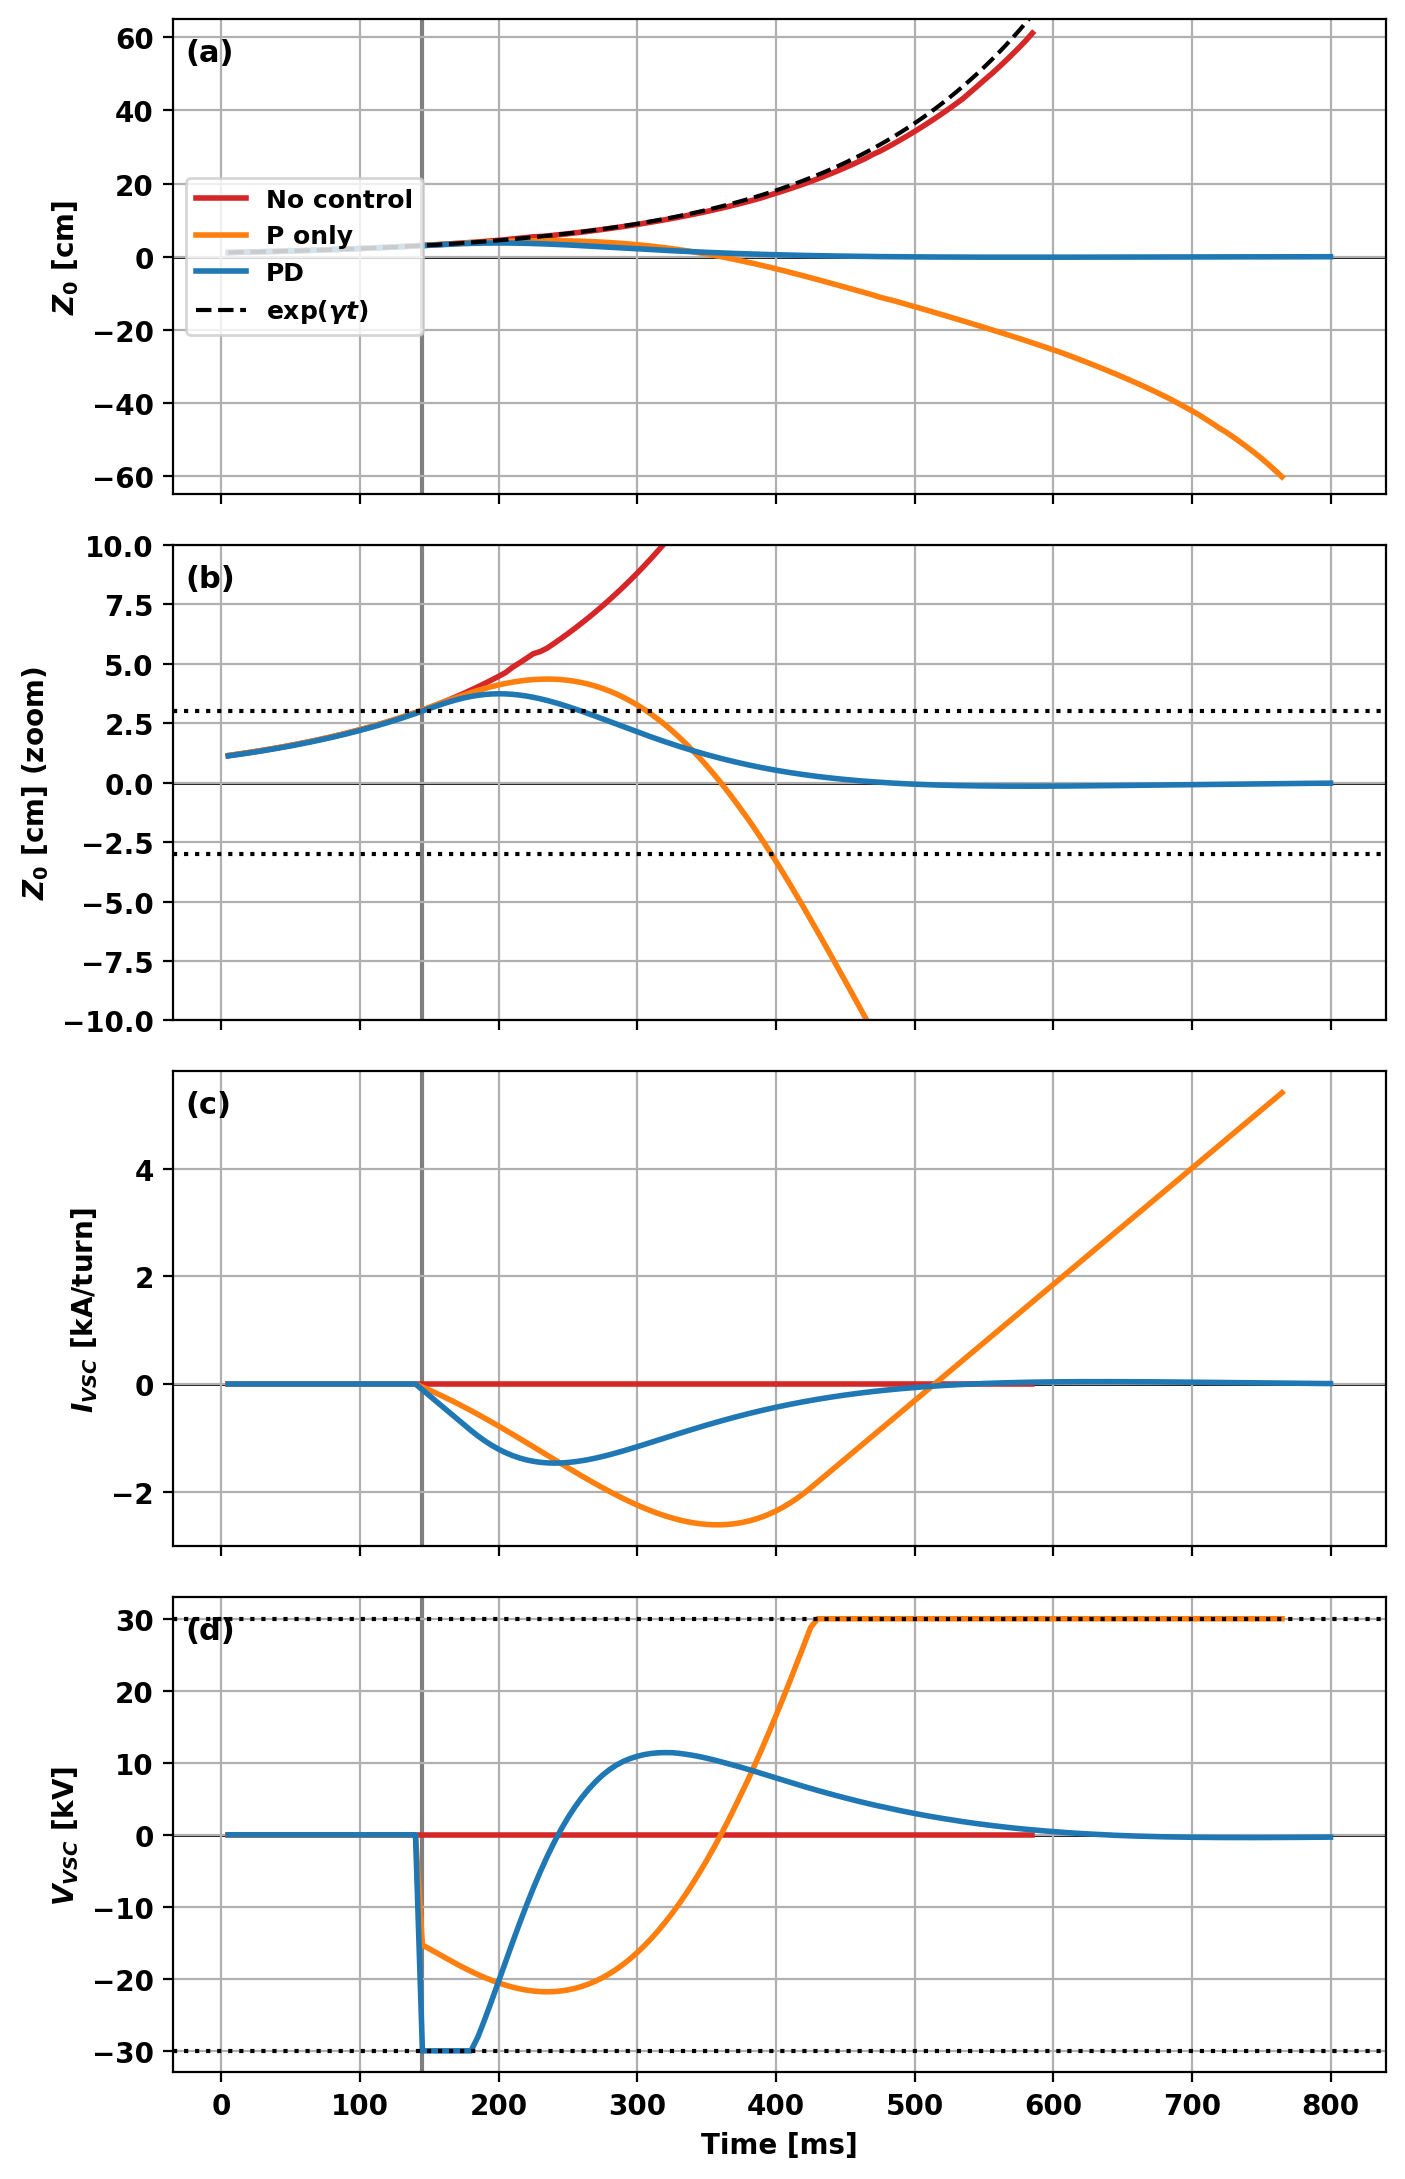

In [15]:
colors = {'No control': 'tab:red', 'P only': 'tab:orange', 'PD': 'tab:blue'}

fig, ax = plt.subplots(4,1,sharex=True,figsize=(7,11))
for label, (hist, _) in results.items():
    for i in (0,1):
        ax[i].plot(hist[:,0]*1.E3, hist[:,1]*1.E2, color=colors[label], label=label)
    ax[2].plot(hist[:,0]*1.E3, hist[:,2]/1.E3, color=colors[label])
    ax[3].plot(hist[:,0]*1.E3, hist[:,3]/1.E3, color=colors[label])

# Linear growth rate of the uncontrolled mode for reference
hist_free = results['No control'][0]
t_ref = hist_free[:,0]
ax[0].plot(t_ref*1.E3, hist_free[0,1]*1.E2*np.exp(gamma_vde*(t_ref-t_ref[0])),
           'k--',lw=1.5,label=r'$\exp(\gamma t)$')

# Detection threshold and the time the controller latches on
for sgn in (1.0,-1.0):
    ax[1].axhline(sgn*z0_thresh*1.E2,color='k',ls=':',lw=1.5)
hist_pd = results['PD'][0]
t_on = hist_pd[hist_pd[:,5] > 0.0, 0]
if len(t_on) > 0:
    for ax_tmp in ax:
        ax_tmp.axvline(t_on[0]*1.E3,color='tab:grey',lw=1.5,zorder=-10)

# Supply voltage limits
for sgn in (1.0,-1.0):
    ax[3].axhline(sgn*V_max/1.E3,color='k',ls=':',lw=1.5)

ax[0].set_ylim(-65.0,65.0)
ax[0].set_ylabel(r'$Z_0$ [cm]')
ax[0].legend(loc='center left',fontsize=9)
ax[1].set_ylim(-10.0,10.0)
ax[1].set_ylabel(r'$Z_0$ [cm] (zoom)')
ax[2].set_ylabel(r'$I_{VSC}$ [kA/turn]')
ax[3].set_ylabel(r'$V_{VSC}$ [kV]')
ax[3].set_xlabel('Time [ms]')
for i, ax_tmp in enumerate(ax):
    ax_tmp.grid(True)
    ax_tmp.axhline(0.0,color='k',lw=1,zorder=-10)
    ax_tmp.text(0.01,0.96,'({0})'.format('abcd'[i]),ha='left',va='top',
                transform=ax_tmp.transAxes,fontsize=11)
_ = fig.tight_layout()

### Plot the final plasma shape

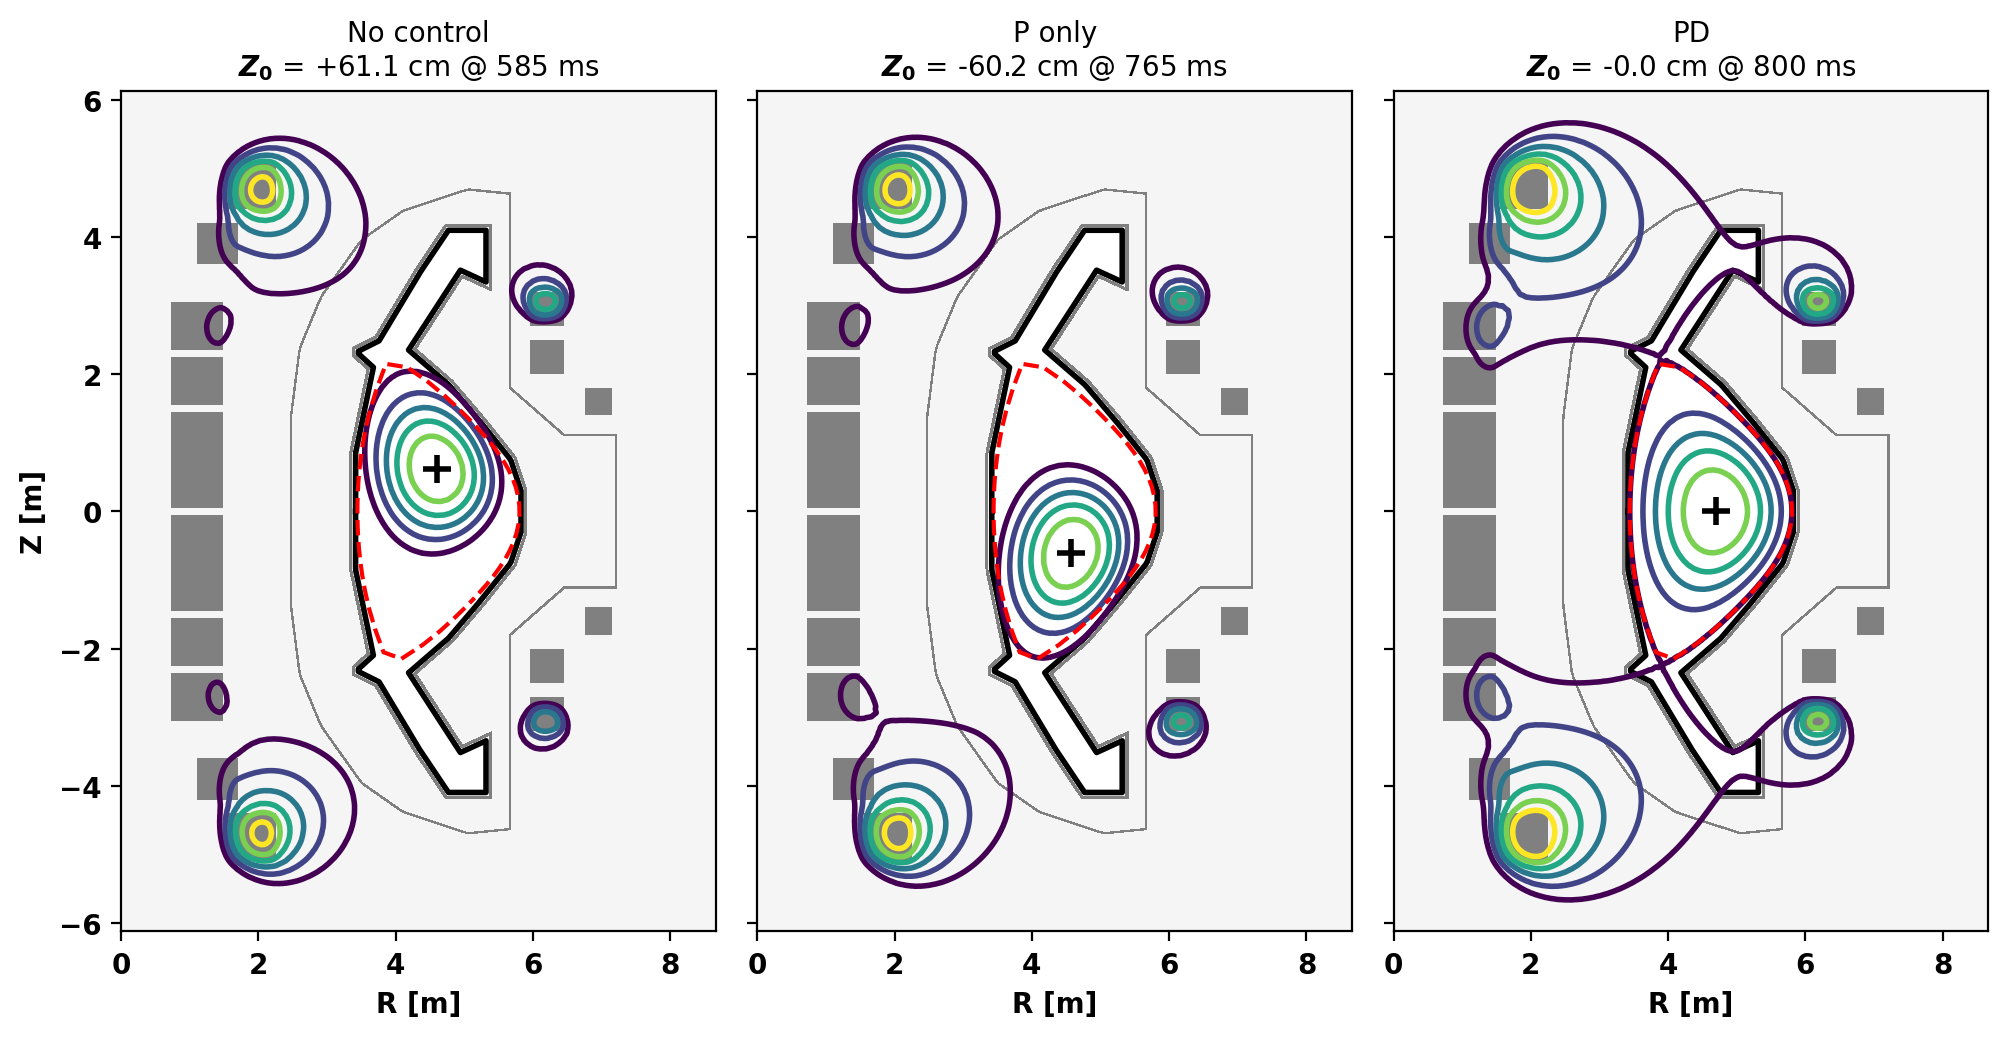

In [16]:
fig, ax = plt.subplots(1,3,sharey=True,constrained_layout=True,figsize=(10,5))
for i, (label, (hist, psi_snaps)) in enumerate(results.items()):
    mygs.plot_machine(fig,ax[i])
    mygs.plot_psi(fig,ax[i],psi=psi_snaps[-1],plasma_nlevels=6,vacuum_nlevels=0,
                  opoint_color=None,xpoint_color=None)
    ax[i].plot(eqdsk['rzout'][::2,0], eqdsk['rzout'][::2,1],'r--',lw=1.5)
    ax[i].plot(hist[-1,4], hist[-1,1], color='k', marker='+', markersize=10)
    ax[i].set_title('{0}\n$Z_0$ = {1:+.1F} cm @ {2:.0F} ms'.format(label,hist[-1,1]*1.E2,hist[-1,0]*1.E3),
                    fontsize=10)
    ax[i].set_xlabel('R [m]')
_ = ax[0].set_ylabel('Z [m]')